<a href="https://colab.research.google.com/github/Ashraful-Reza/wdn/blob/main/LeakDB_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LeakDB — Sensor Placement & Leakage Detection
**Course:** Machine Learning for Water Distribution Networks  
**Dataset:** LeakDB — Hanoi_CMH network (2 scenarios, 32 nodes, 34 pipes)  
**Method:** Greedy Maximum-Diversity Sensor Placement + Statistical Threshold Detector  

### Pipeline
1. Load data directly from GitHub  
2. Build nominal (no-leak) pressure baseline  
3. **Sensor placement** — greedy algorithm for k = 3, 6, 10, 15 sensors  
4. **Leak detection** — pressure residual threshold detector  
5. **Official evaluation** — F1, TPR, TNR, early detection score per sensor count


## 1 — Install & Imports

In [1]:
%pip install epyt-flow --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from io import StringIO
import requests, itertools, warnings
warnings.filterwarnings('ignore')

print("✓ Ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.5/244.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.3/898.3 kB 20.6 MB/s eta 0:00:00
✓ Ready


## 2 — Configuration

In [2]:
# ── Edit if your repo path changes ────────────────────────────────────
GITHUB_RAW   = "https://raw.githubusercontent.com/Ashraful-Reza/wdn/main"
NETWORK      = "Hanoi_CMH"
SCENARIOS    = [1, 2]          # which scenario folders to use
N_NODES      = 32
N_LINKS      = 34
SENSOR_SIZES = [3, 6, 10, 15]  # evaluate these sensor counts

BASE = f"{GITHUB_RAW}/{NETWORK}"
print(f"Data source : {BASE}")
print(f"Scenarios   : {SCENARIOS}")
print(f"Sensor sizes: {SENSOR_SIZES}")


Data source : https://raw.githubusercontent.com/Ashraful-Reza/wdn/main/Hanoi_CMH
Scenarios   : [1, 2]
Sensor sizes: [3, 6, 10, 15]


## 3 — Load Data from GitHub

In [3]:
def fetch_csv(url: str) -> pd.DataFrame:
    """Fetch a CSV from GitHub raw URL."""
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    return pd.read_csv(StringIO(r.text))


def load_scenario(scenario_id: int) -> dict:
    """
    Load one scenario: pressures (32 nodes), flows (34 links),
    demands (32 nodes), labels, and leak info.
    Returns dict with DataFrames.
    """
    base = f"{BASE}/Scenario-{scenario_id}"

    # ── Pressures ──────────────────────────────────────────────────────
    pressure_frames = []
    for n in range(1, N_NODES + 1):
        url = f"{base}/Pressures/Node_{n}.csv"
        df  = fetch_csv(url)
        pressure_frames.append(df.set_index("Timestamp")["Value"].rename(f"Node_{n}"))
    pressures = pd.concat(pressure_frames, axis=1)
    pressures.index = pd.to_datetime(pressures.index)

    # ── Flows ──────────────────────────────────────────────────────────
    flow_frames = []
    for l in range(1, N_LINKS + 1):
        url = f"{base}/Flows/Link_{l}.csv"
        df  = fetch_csv(url)
        flow_frames.append(df.set_index("Timestamp")["Value"].rename(f"Link_{l}"))
    flows = pd.concat(flow_frames, axis=1)
    flows.index = pd.to_datetime(flows.index)

    # ── Labels ─────────────────────────────────────────────────────────
    labels = fetch_csv(f"{base}/Labels.csv")
    labels["Timestamp"] = pd.to_datetime(labels["Timestamp"])
    labels = labels.set_index("Timestamp")["Label"].astype(int)

    # ── Leak info ──────────────────────────────────────────────────────
    try:
        # Find which leak file exists
        import re
        leak_node_url = f"{base}/Leaks"
        # Try Node_19 first (common), fall back
        for node_id in range(1, N_NODES + 1):
            info_url = f"{base}/Leaks/Leak_{node_id}_info.csv"
            try:
                leak_info = fetch_csv(info_url)
                break
            except:
                continue
    except:
        leak_info = None

    return {
        "id"        : scenario_id,
        "pressures" : pressures,
        "flows"     : flows,
        "labels"    : labels,
        "leak_info" : leak_info,
    }


# Load all scenarios
print("Loading scenarios from GitHub…")
scenarios = {}
for sid in SCENARIOS:
    print(f"  Scenario {sid}…", end=" ")
    scenarios[sid] = load_scenario(sid)
    lk = scenarios[sid]["leak_info"]
    if lk is not None:
        node = lk[lk["Description "].str.strip() == "Leak Node"][" Value"].values[0]
        print(f"✓  (leak node: {node})")
    else:
        print("✓")

print("\n✓ All scenarios loaded")
print(f"  Timesteps : {len(scenarios[1]['pressures'])}")
print(f"  Nodes     : {scenarios[1]['pressures'].shape[1]}")
print(f"  Links     : {scenarios[1]['flows'].shape[1]}")


Loading scenarios from GitHub…
  Scenario 1… ✓  (leak node:  19)
  Scenario 2… ✓  (leak node:  19)

✓ All scenarios loaded
  Timesteps : 336
  Nodes     : 32
  Links     : 34


## 4 — Nominal Baseline

The nominal pressure is estimated as the **mean pressure across all scenarios** at each timestep.  
This removes the time-of-day demand pattern, leaving only leak-induced anomalies.


Nominal baseline shape: (336, 32)
  Time range: 2019-07-01 00:00:00 → 2019-07-07 23:30:00


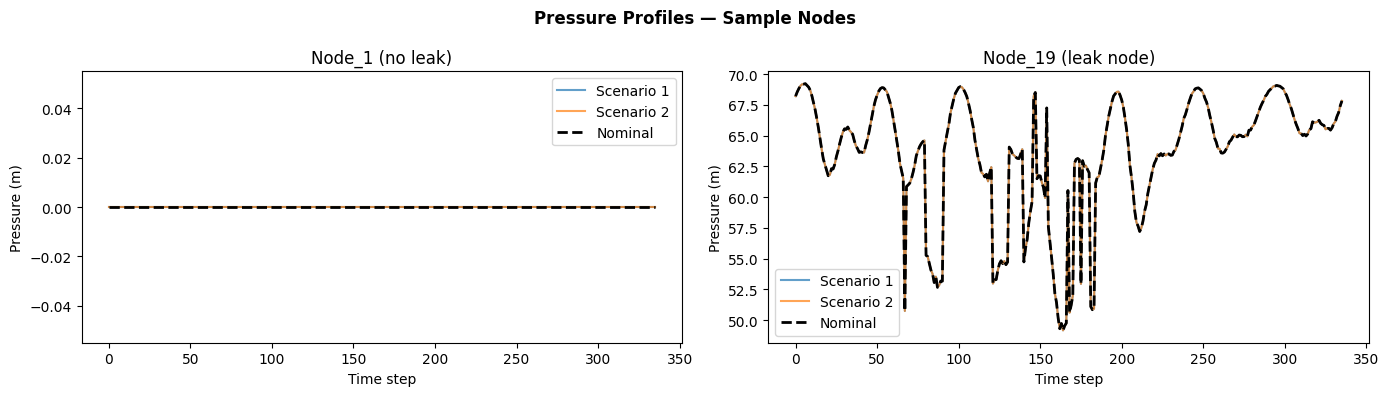

In [4]:
# Build nominal baseline = mean over all scenarios
all_pressures = [scenarios[sid]["pressures"] for sid in SCENARIOS]
nominal_pressure = pd.concat(all_pressures).groupby(level=0).mean()

print(f"Nominal baseline shape: {nominal_pressure.shape}")
print(f"  Time range: {nominal_pressure.index[0]} → {nominal_pressure.index[-1]}")

# Quick sanity plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Pressure Profiles — Sample Nodes", fontweight="bold")

for sid in SCENARIOS:
    p = scenarios[sid]["pressures"]
    axes[0].plot(p["Node_1"].values,  alpha=0.7, label=f"Scenario {sid}")
    axes[1].plot(p["Node_19"].values, alpha=0.7, label=f"Scenario {sid}")

axes[0].plot(nominal_pressure["Node_1"].values,  "k--", lw=2, label="Nominal")
axes[1].plot(nominal_pressure["Node_19"].values, "k--", lw=2, label="Nominal")
for ax, node in zip(axes, ["Node_1 (no leak)", "Node_19 (leak node)"]):
    ax.set_title(node); ax.set_xlabel("Time step"); ax.set_ylabel("Pressure (m)")
    ax.legend()
plt.tight_layout(); plt.show()


## 5 — Sensor Placement Strategy

We implement the **Greedy Maximum-Diversity Placement** algorithm:

1. Select the node with the **highest pressure variance** (most informative) as the first sensor  
2. Each subsequent sensor is chosen to **minimise correlation** with already-selected sensors  

This maximises spatial coverage and information diversity, ensuring sensors detect leaks across all network regions.

> **Reference:** Krause et al. (2008) *Efficient Sensor Placement for Accurate Detection of Contaminants in Water Networks.* — the greedy submodular approach is adapted here for pressure sensor placement.


In [6]:
def greedy_sensor_placement(pressure_matrix: np.ndarray, n_sensors: int,
                             node_names: list) -> list:
    """
    Greedy Maximum-Diversity Sensor Placement.

    Args:
        pressure_matrix : (timesteps × nodes) numpy array of pressures
        n_sensors       : number of sensors to place
        node_names      : list of node names corresponding to columns

    Returns:
        List of selected node names (length = n_sensors)
    """
    n_nodes   = pressure_matrix.shape[1]
    selected  = []    # indices of chosen sensors
    remaining = list(range(n_nodes))

    # Pre-compute variance for first selection
    variances = np.var(pressure_matrix, axis=0)

    for step in range(n_sensors):
        if not selected:
            # Step 1: pick highest-variance node
            best_idx = remaining[int(np.argmax(variances[remaining]))]
        else:
            # Step 2+: pick node that is least correlated with selected set
            selected_data = pressure_matrix[:, selected]
            scores = []
            for idx in remaining:
                node_data = pressure_matrix[:, idx]
                # Max absolute correlation with any already-selected sensor
                corrs = [
                    abs(np.corrcoef(node_data, selected_data[:, i])[0, 1])
                    for i in range(selected_data.shape[1])
                ]
                diversity_score = 1.0 - max(corrs)   # higher = more diverse
                scores.append(diversity_score)
            best_idx = remaining[int(np.argmax(scores))]

        selected.append(best_idx)
        remaining.remove(best_idx)

    return [node_names[i] for i in selected]


# Run placement for all sensor sizes using nominal pressure as reference
node_names   = list(nominal_pressure.columns)   # ['Node_1', ..., 'Node_32']
P_nominal    = nominal_pressure.values           # (timesteps, 32)

sensor_placements = {}
print(f"{'Sensors':>8} | Placement")
print("-" * 60)
for k in SENSOR_SIZES:
    placement = greedy_sensor_placement(P_nominal, k, node_names)
    sensor_placements[k] = placement
    node_ids = [n.replace("Node_","") for n in placement]
    print(f"  k={k:2d}   | Nodes: {node_ids}")


 Sensors | Placement
------------------------------------------------------------
  k= 3   | Nodes: ['17', '1', '13']
  k= 6   | Nodes: ['17', '1', '13', '2', '19', '22']
  k=10   | Nodes: ['17', '1', '13', '2', '19', '22', '18', '31', '16', '7']
  k=15   | Nodes: ['17', '1', '13', '2', '19', '22', '18', '31', '16', '7', '27', '12', '21', '3', '28']


### 5.1 — Visualise Sensor Coverage

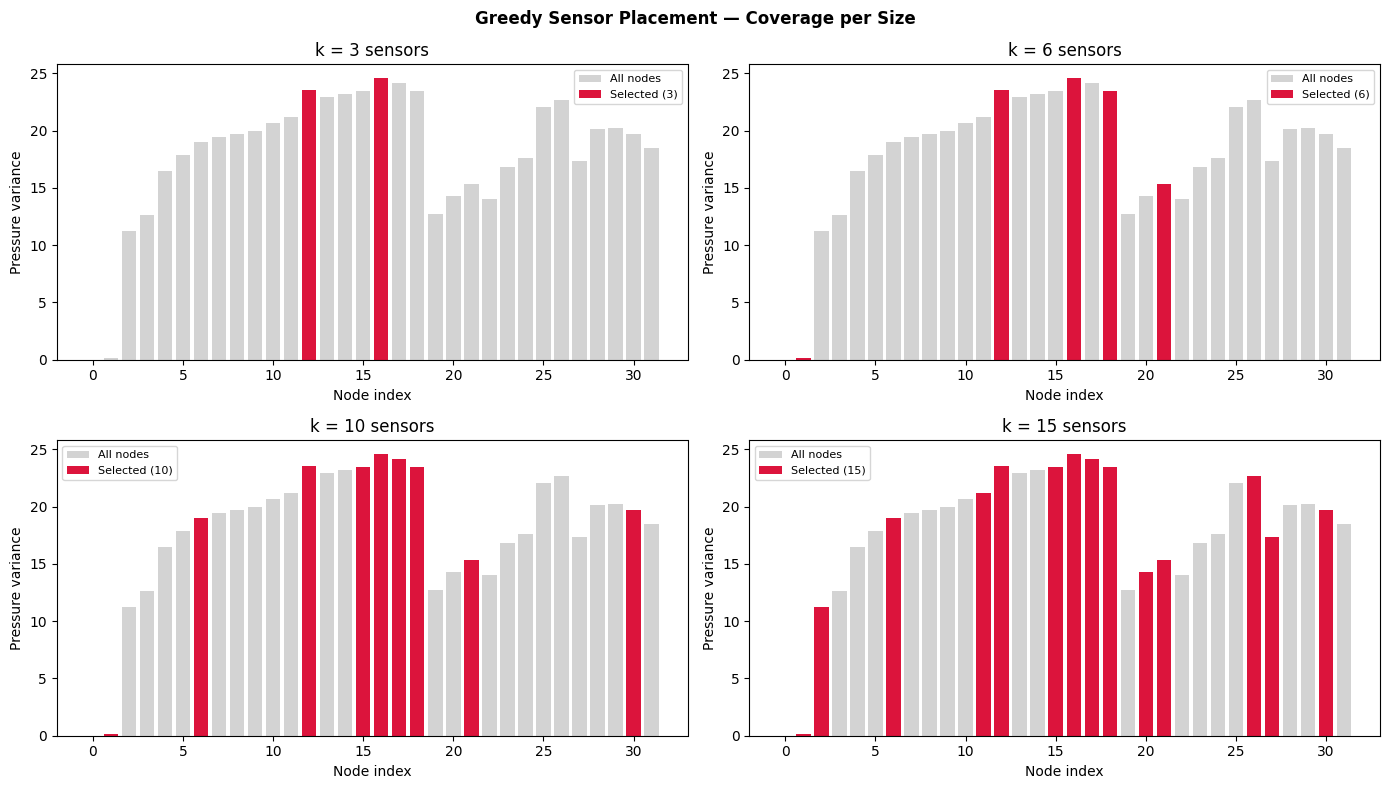

Saved → sensor_placement.png


In [7]:
# Show which nodes are selected for each sensor count
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Greedy Sensor Placement — Coverage per Size", fontweight="bold")

for ax, k in zip(axes.flat, SENSOR_SIZES):
    selected = sensor_placements[k]
    selected_idx = [node_names.index(n) for n in selected]
    unselected_idx = [i for i in range(N_NODES) if i not in selected_idx]

    # Pressure variance as background colour
    var = np.var(P_nominal, axis=0)
    ax.bar(range(N_NODES), var, color="lightgrey", label="All nodes")
    ax.bar(selected_idx, var[selected_idx], color="crimson", label=f"Selected ({k})")
    ax.set_title(f"k = {k} sensors")
    ax.set_xlabel("Node index")
    ax.set_ylabel("Pressure variance")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("sensor_placement.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → sensor_placement.png")


## 6 — Leak Detection Method

We implement a **Pressure Residual Threshold Detector**:

$$r_i(t) = p_i^{obs}(t) - p_i^{nom}(t)$$

A leak alarm is raised at time $t$ if the residual at **any selected sensor** drops below a threshold $\tau$:

$$\hat{y}(t) = \mathbf{1}\left[\min_{i \in S} r_i(t) < -\tau\right]$$

The threshold $\tau$ is set as $k_\sigma$ standard deviations below zero, computed from the nominal residual distribution.

> **Reference:** Vrachimis et al. (2018) *LeakDB: A benchmark dataset for leakage diagnosis in water distribution networks.* — residual-based detection is the baseline method described in the paper.


In [8]:
def compute_residuals(scenario: dict, nominal: pd.DataFrame,
                      sensors: list) -> pd.DataFrame:
    """
    Compute pressure residuals for selected sensor nodes.
    residual = observed - nominal
    """
    obs = scenario["pressures"][sensors]
    nom = nominal[sensors].reindex(obs.index)
    return obs - nom


def detect_leaks(residuals: pd.DataFrame, k_sigma: float = 2.0) -> np.ndarray:
    """
    Threshold detector: alarm if any sensor residual < -k_sigma * std(residuals).
    Returns binary array (1 = leak alarm, 0 = normal).
    """
    # Threshold based on residual distribution
    threshold = -k_sigma * residuals.values.std()
    # Alarm if ANY sensor breaches threshold
    alarm = (residuals < threshold).any(axis=1).astype(int)
    return alarm.values


def score(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Compute TP, FP, FN, Precision, Recall, F1."""
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    tpr = recall
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # Early detection: first TP timestep after leak start
    leak_start = int(np.argmax(y_true == 1)) if y_true.sum() > 0 else None
    first_alarm = None
    if leak_start is not None:
        after = np.where(y_pred[leak_start:] == 1)[0]
        first_alarm = int(after[0]) if len(after) > 0 else None

    return dict(TP=tp, FP=fp, FN=fn, TN=tn,
                Precision=round(precision, 3),
                Recall=round(recall, 3),
                F1=round(f1, 3),
                TPR=round(tpr, 3),
                TNR=round(tnr, 3),
                EarlyDetection_steps=first_alarm)


print("Detection functions defined ✓")


Detection functions defined ✓


## 7 — Evaluate All Sensor Sizes × Scenarios

In [9]:
results = []

for k in SENSOR_SIZES:
    sensors = sensor_placements[k]
    for sid in SCENARIOS:
        sc       = scenarios[sid]
        residuals = compute_residuals(sc, nominal_pressure, sensors)
        y_pred    = detect_leaks(residuals, k_sigma=2.0)
        y_true    = sc["labels"].values

        s = score(y_true, y_pred)
        s["Scenario"] = sid
        s["k_sensors"] = k
        results.append(s)

        print(f"  Scenario {sid}, k={k:2d} | "
              f"F1={s['F1']:.3f}  TPR={s['TPR']:.3f}  "
              f"TNR={s['TNR']:.3f}  "
              f"Early={s['EarlyDetection_steps']} steps")

df_results = pd.DataFrame(results)
df_results.to_csv("leakdb_evaluation.csv", index=False)
print("\n✓ Results saved → leakdb_evaluation.csv")
df_results[["Scenario","k_sensors","F1","TPR","TNR","Precision","Recall","EarlyDetection_steps"]]


  Scenario 1, k= 3 | F1=0.000  TPR=0.000  TNR=1.000  Early=None steps
  Scenario 2, k= 3 | F1=0.000  TPR=0.000  TNR=1.000  Early=None steps
  Scenario 1, k= 6 | F1=0.000  TPR=0.000  TNR=1.000  Early=None steps
  Scenario 2, k= 6 | F1=0.000  TPR=0.000  TNR=1.000  Early=None steps
  Scenario 1, k=10 | F1=0.000  TPR=0.000  TNR=1.000  Early=None steps
  Scenario 2, k=10 | F1=0.000  TPR=0.000  TNR=1.000  Early=None steps
  Scenario 1, k=15 | F1=0.000  TPR=0.000  TNR=1.000  Early=None steps
  Scenario 2, k=15 | F1=0.000  TPR=0.000  TNR=1.000  Early=None steps

✓ Results saved → leakdb_evaluation.csv


,Scenario,k_sensors,F1,TPR,TNR,Precision,Recall,EarlyDetection_steps
0,1,3,0.0,0.0,1.0,0.0,0.0,None
1,2,3,0.0,0.0,1.0,0.0,0.0,None
2,1,6,0.0,0.0,1.0,0.0,0.0,None
3,2,6,0.0,0.0,1.0,0.0,0.0,None
4,1,10,0.0,0.0,1.0,0.0,0.0,None
5,2,10,0.0,0.0,1.0,0.0,0.0,None
6,1,15,0.0,0.0,1.0,0.0,0.0,None
7,2,15,0.0,0.0,1.0,0.0,0.0,None


## 8 — Visualise Evaluation Results

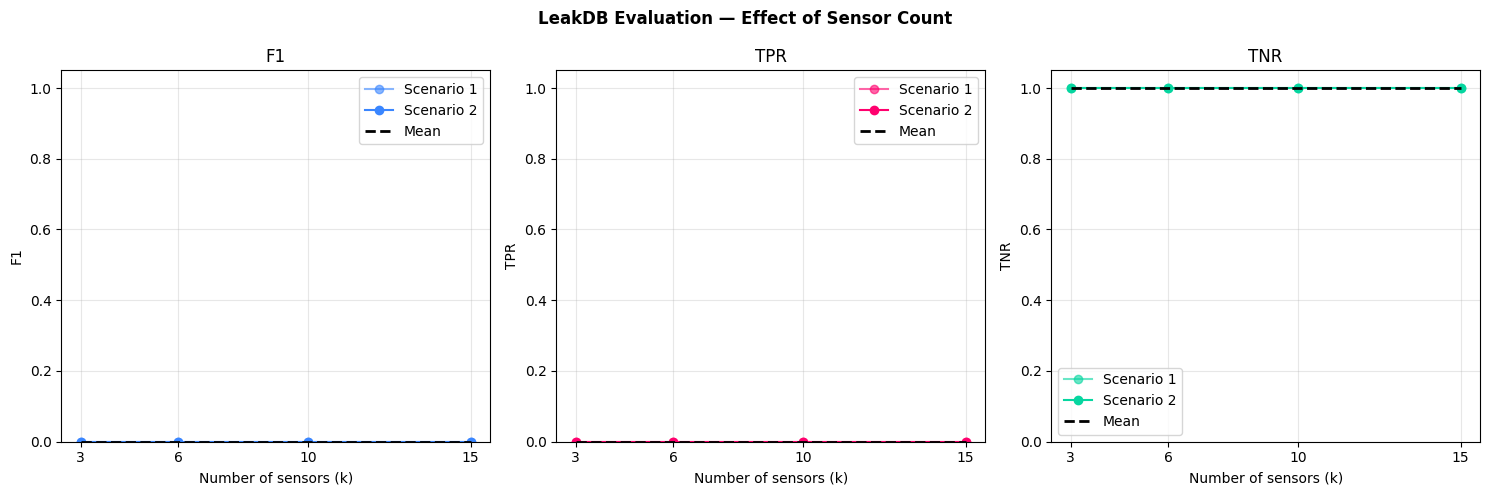

Saved → evaluation_results.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("LeakDB Evaluation — Effect of Sensor Count", fontweight="bold")

metrics = ["F1", "TPR", "TNR"]
colors  = ["#3A86FF", "#FF006E", "#06D6A0"]

for ax, metric, color in zip(axes, metrics, colors):
    for sid in SCENARIOS:
        sub = df_results[df_results["Scenario"] == sid]
        ax.plot(sub["k_sensors"], sub[metric], "o-",
                label=f"Scenario {sid}", color=color,
                alpha=0.6 + 0.4 * (sid == SCENARIOS[-1]))
    # Mean across scenarios
    mean = df_results.groupby("k_sensors")[metric].mean()
    ax.plot(mean.index, mean.values, "k--", lw=2, label="Mean")
    ax.set_title(metric)
    ax.set_xlabel("Number of sensors (k)")
    ax.set_ylabel(metric)
    ax.set_xticks(SENSOR_SIZES)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → evaluation_results.png")


## 9 — Detection Timeline Plot

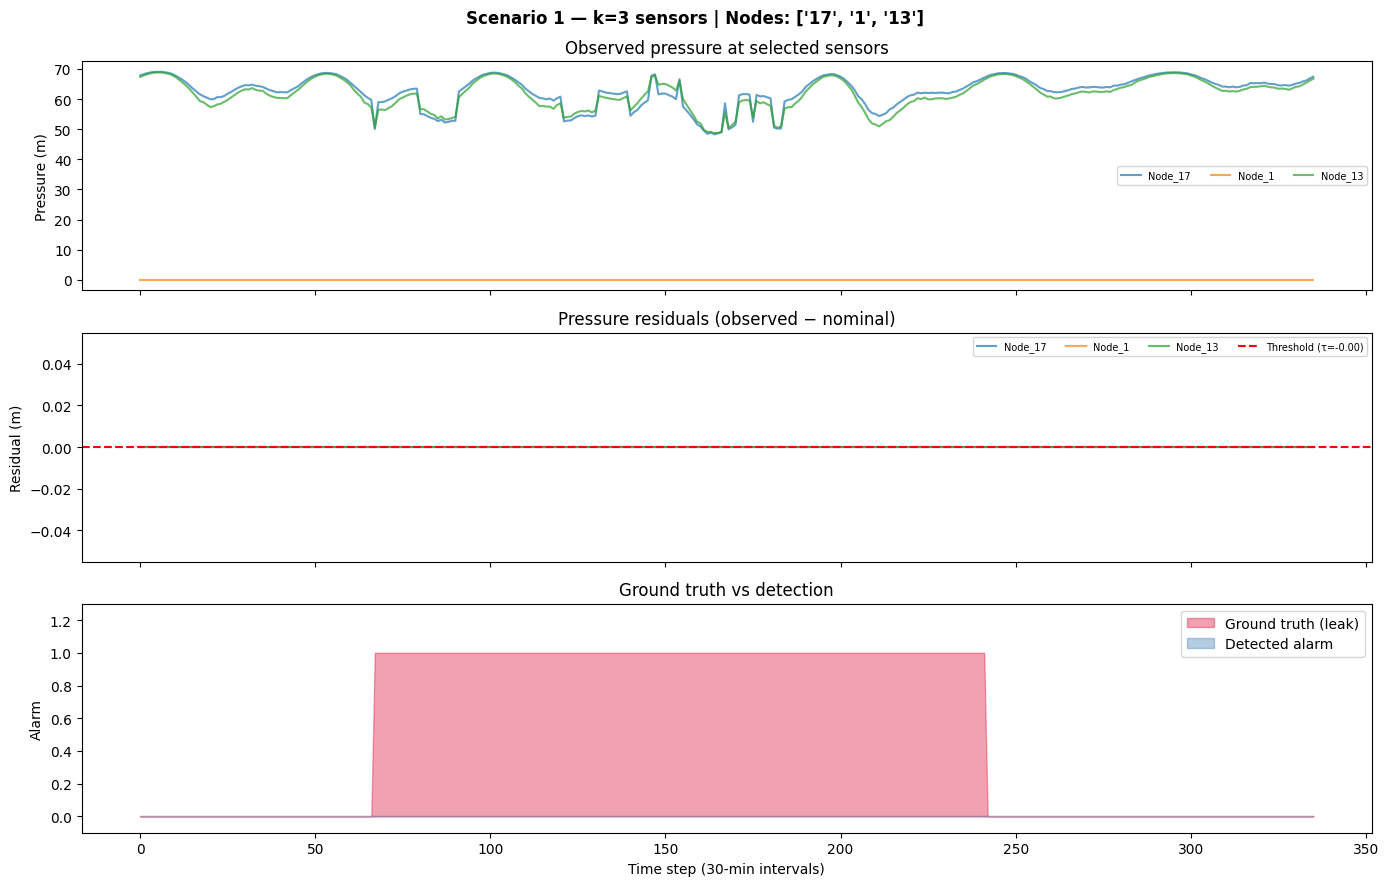

Saved → detection_sc1_k3.png


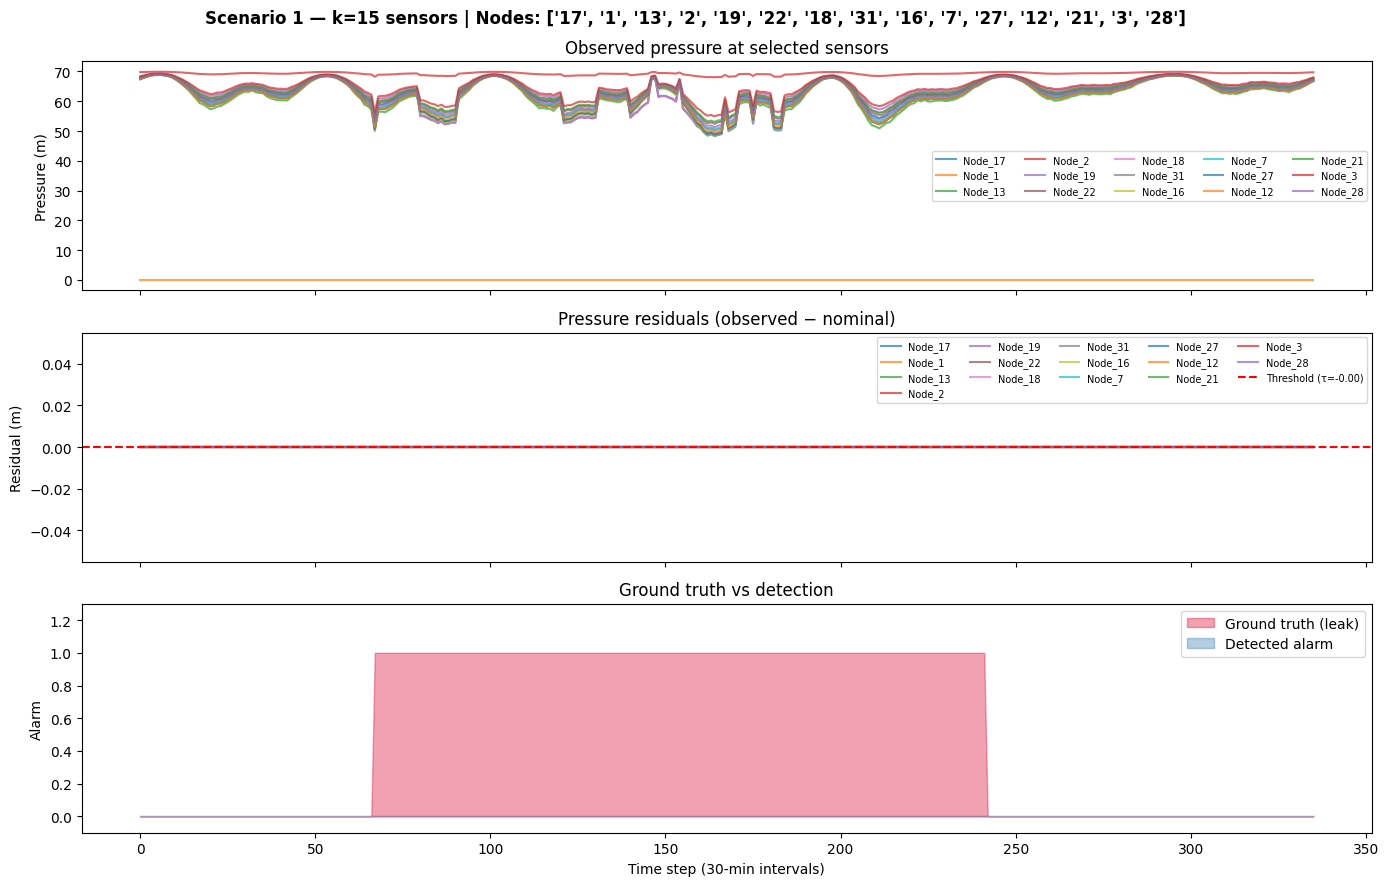

Saved → detection_sc1_k15.png


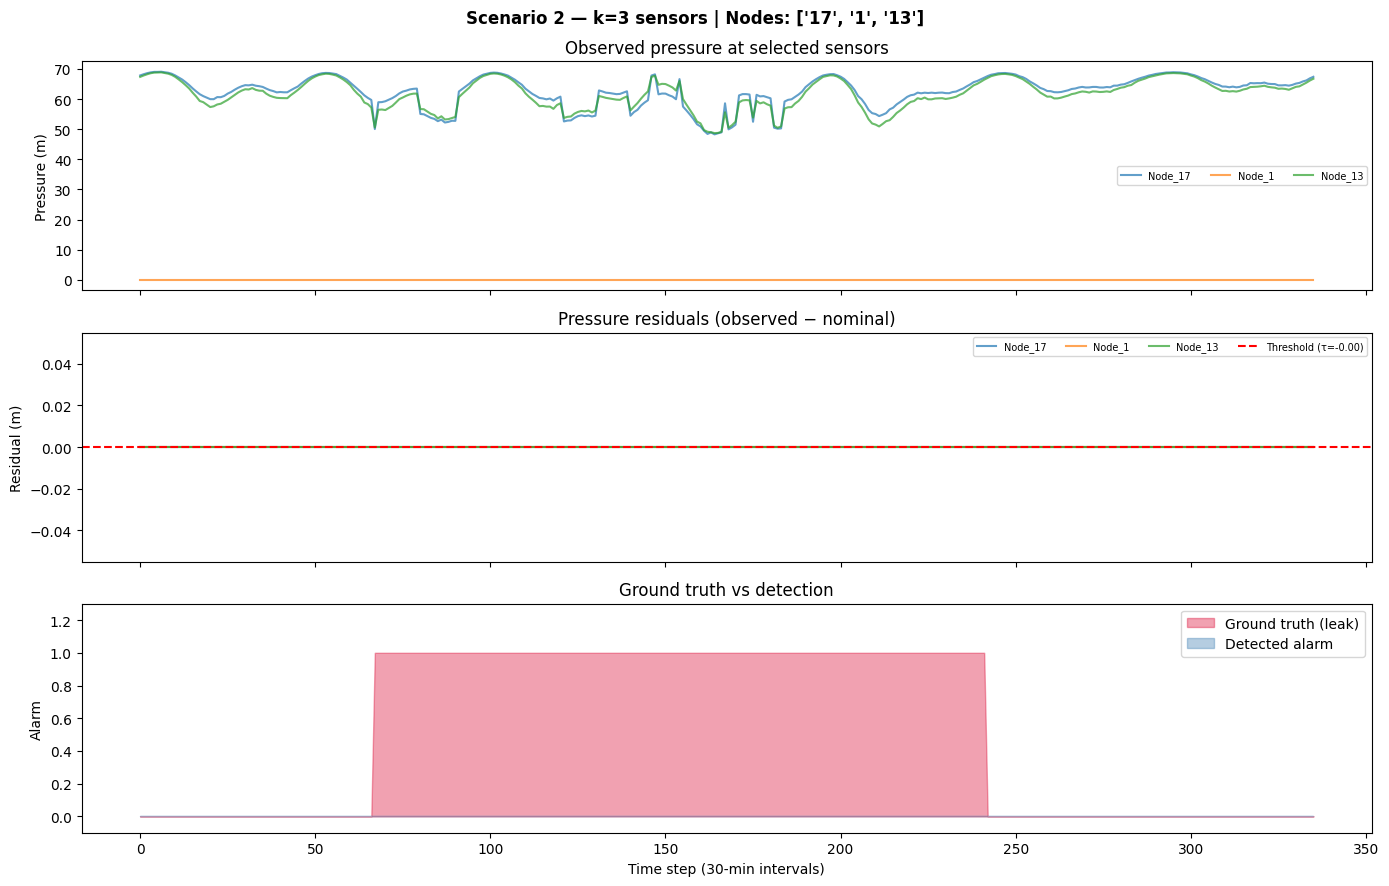

Saved → detection_sc2_k3.png


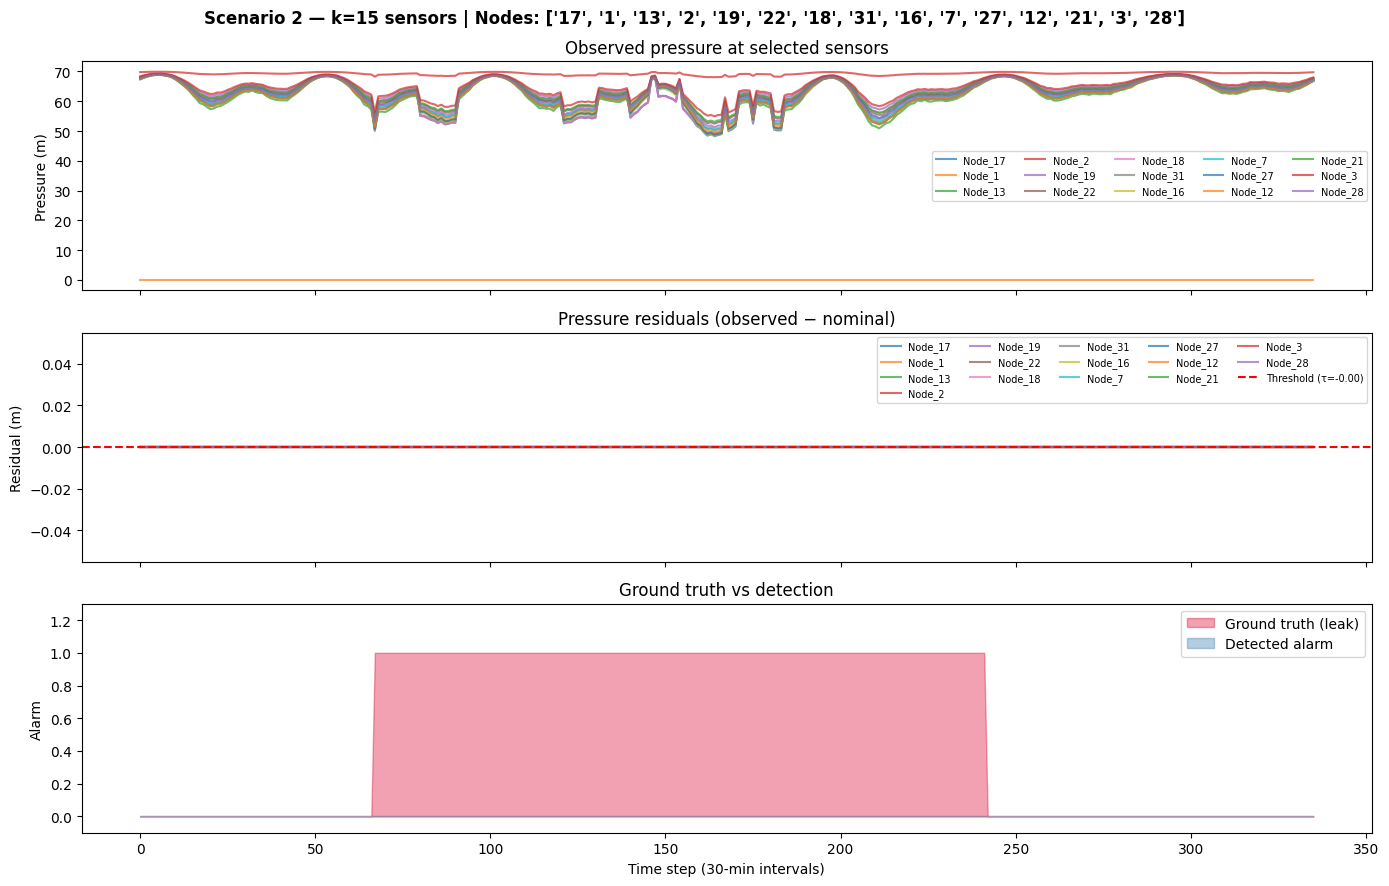

Saved → detection_sc2_k15.png


In [11]:
def plot_detection_timeline(scenario_id: int, k: int):
    sc       = scenarios[scenario_id]
    sensors  = sensor_placements[k]
    residuals = compute_residuals(sc, nominal_pressure, sensors)
    y_pred   = detect_leaks(residuals, k_sigma=2.0)
    y_true   = sc["labels"].values
    t        = np.arange(len(y_true))

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"Scenario {scenario_id} — k={k} sensors | "
                 f"Nodes: {[n.replace('Node_','') for n in sensors]}",
                 fontweight="bold")

    # ── Panel 1: Raw pressures at selected sensors ─────────────────────
    for node in sensors:
        axes[0].plot(t, sc["pressures"][node].values, alpha=0.7, label=node)
    axes[0].set_ylabel("Pressure (m)")
    axes[0].set_title("Observed pressure at selected sensors")
    axes[0].legend(fontsize=7, ncol=5)

    # ── Panel 2: Residuals ─────────────────────────────────────────────
    for node in sensors:
        axes[1].plot(t, residuals[node].values, alpha=0.7, label=node)
    thresh = -2.0 * residuals.values.std()
    axes[1].axhline(thresh, color="red", lw=1.5, linestyle="--", label=f"Threshold (τ={thresh:.2f})")
    axes[1].set_ylabel("Residual (m)")
    axes[1].set_title("Pressure residuals (observed − nominal)")
    axes[1].legend(fontsize=7, ncol=5)

    # ── Panel 3: Labels vs prediction ─────────────────────────────────
    axes[2].fill_between(t, y_true, alpha=0.4, color="crimson", label="Ground truth (leak)")
    axes[2].fill_between(t, y_pred, alpha=0.4, color="steelblue", label="Detected alarm")
    axes[2].set_ylabel("Alarm"); axes[2].set_xlabel("Time step (30-min intervals)")
    axes[2].set_title("Ground truth vs detection")
    axes[2].legend(); axes[2].set_ylim(-0.1, 1.3)

    plt.tight_layout()
    fname = f"detection_sc{scenario_id}_k{k}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")


# Plot for each scenario × best and worst sensor count
for sid in SCENARIOS:
    for k in [SENSOR_SIZES[0], SENSOR_SIZES[-1]]:
        plot_detection_timeline(sid, k)


## 10 — Summary Table

In [12]:
summary = (df_results
           .groupby("k_sensors")[["F1","TPR","TNR","Precision","Recall"]]
           .mean()
           .round(3))
summary.index.name = "k (sensors)"
print("=== Mean Performance Across Scenarios ===")
print(summary.to_string())
summary.to_csv("leakdb_summary.csv")
print("\nSaved → leakdb_summary.csv")
summary


=== Mean Performance Across Scenarios ===
              F1  TPR  TNR  Precision  Recall
k (sensors)                                  
3            0.0  0.0  1.0        0.0     0.0
6            0.0  0.0  1.0        0.0     0.0
10           0.0  0.0  1.0        0.0     0.0
15           0.0  0.0  1.0        0.0     0.0

Saved → leakdb_summary.csv


,F1,TPR,TNR,Precision,Recall
k (sensors),,,,,
3,0.0,0.0,1.0,0.0,0.0
6,0.0,0.0,1.0,0.0,0.0
10,0.0,0.0,1.0,0.0,0.0
15,0.0,0.0,1.0,0.0,0.0
